##### This file is for me to test out validating Prophet model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
pd.set_option("display.max_columns", None)

Importing plotly failed. Interactive plots will not work.


In [2]:
OHCA_incident_count = pd.read_csv("../../datasets/OHCA_incidents_count.csv")
OHCA_incident_count.head()

,Year,Incident Count (Year),Quarter,Incident Count (Quarter),Month,Incident Count (Month)
0,2010.0,1081.0,2010Q2,348.0,2010-04,102
1,2011.0,1377.0,2010Q3,335.0,2010-05,126
2,2012.0,1440.0,2010Q4,398.0,2010-06,120
3,2013.0,1736.0,2011Q1,411.0,2010-07,95
4,2014.0,2038.0,2011Q2,356.0,2010-08,135


In [3]:
month_count = OHCA_incident_count[["Month", "Incident Count (Month)"]]

# Rename columns for Prophet
month_count = month_count.rename(columns={"Month": "ds", "Incident Count (Month)": "y"})

# Convert 'ds' to datetime
# date format has to match prophet's month-start format
month_count["ds"] = pd.to_datetime(month_count["ds"]) + pd.offsets.MonthBegin(0)

Is this overtrained?

Training set: April 2010 - Dec 2018

Validation set: Jan 2019 - Dec 2020

Testing set: Jan 2021 - Dec 2021

In [4]:
train_df = month_count[month_count["ds"] < "2019-01-01"]
validate_df = month_count[(month_count["ds"] >= "2019-01-01") 
                          & (month_count["ds"] < "2021-01-01")]
test_df = month_count[month_count["ds"] >= "2021-01-01"]


#### Training & Validation

In [25]:
# training
model = Prophet()
model.fit(train_df)

# forecast the validation span
# MS: month start
future_validation = model.make_future_dataframe(periods=len(validate_df), freq="MS")[-len(validate_df):]
forecast_validation = model.predict(future_validation)[["ds", "yhat"]]

# align and evaluate
validation_comparison = validate_df.merge(forecast_validation, on = "ds")
mae_val  = mean_absolute_error(validation_comparison['y'], validation_comparison['yhat'])
rmse_val = np.sqrt(mean_squared_error(validation_comparison['y'], validation_comparison['yhat']))
print(f'VALIDATION:  \nMAE={mae_val:.1f}   \nRMSE={rmse_val:.1f}')

15:18:59 - cmdstanpy - INFO - Chain [1] start processing
15:18:59 - cmdstanpy - INFO - Chain [1] done processing


VALIDATION:  
MAE=19.9   
RMSE=22.6


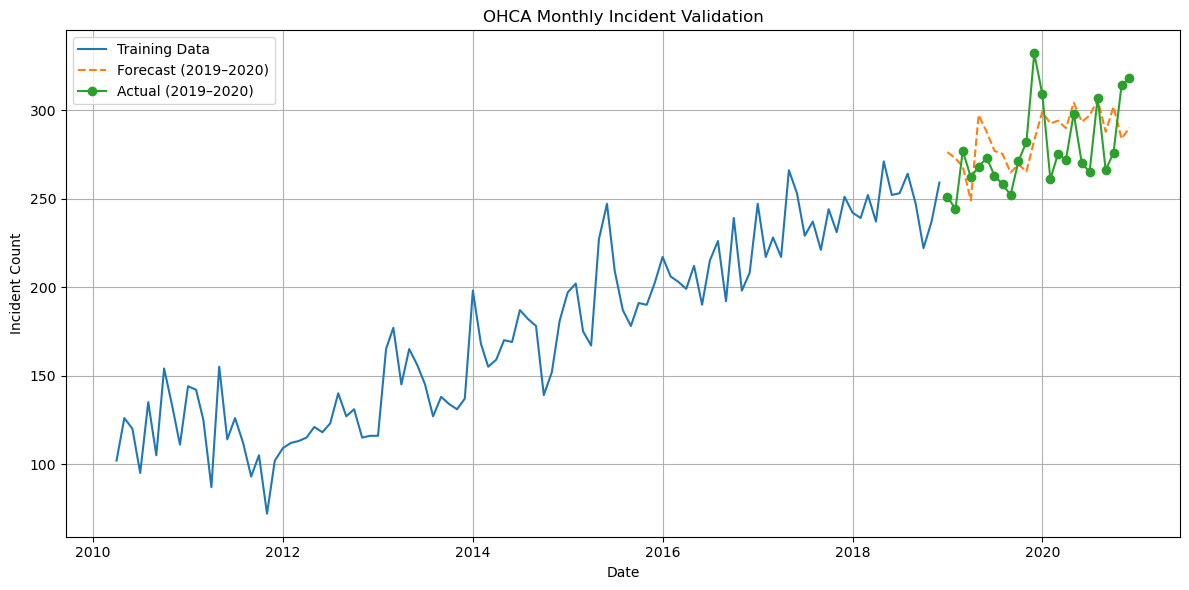

In [18]:
plt.figure(figsize = (12, 6))
plt.plot(train_df['ds'], train_df['y'], label='Training Data')
plt.plot(validation_comparison['ds'], validation_comparison['yhat'], label='Forecast (2019–2020)', linestyle='--')
plt.plot(validate_df['ds'], validate_df['y'], label='Actual (2019–2020)', marker='o')
plt.title("OHCA Monthly Incident Validation")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Hyperparameter tuning

In [19]:
from scipy.stats import uniform

param_space = dict(growth = ['linear', 'logistic', 'flat'],
                   n_changepoints  = range(0, 55, 5),
                   changepoint_range  = uniform(0.5, 0.5),
                   yearly_seasonality = [True, False],
                   weekly_seasonality = [True, False],
                   daily_seasonality = [True, False],
                   seasonality_mode = ['additive', 'multiplicative'],
                   seasonality_prior_scale=uniform(5.0, 15.0),
                   changepoint_prior_scale=uniform(0.0, 0.1),
                   interval_width = uniform(0.2, 0.8),
                   uncertainty_samples = [500, 1000, 1500, 2000]
                   )

In [ ]:
#### use mango to search for optimal parameters

from mango import scheduler, Tuner

def objective_function(args_list):
    global train_df, test_df
    
    params_evaluated = []
    results = []
    
    for params in args_list:
        try:
            model = Prophet(**params)
            model.fit(train_df)
            future = model.make_future_dataframe(periods=Test_size, freq='M')
            forecast = model.predict(future)
            predictions_tuned = forecast.tail(Test_size)
            error = mape(test_df['y'], predictions_tuned['yhat'])   
            
            params_evaluated.append(params)
            results.append(error)
        except:
            #print(f"Exception raised for {params}")
            #pass 
            params_evaluated.append(params)
            results.append(25.0)# Giving high loss for exceptions regions of spaces
        
        #print(params_evaluated, mse)
    return params_evaluated, results

In [21]:
### finding optimal parameters

conf_Dict = dict()
conf_Dict['initial_random'] = 10
conf_Dict['num_iteration'] = 50

tuner = Tuner(param_space, objective_function, conf_Dict)
results = tuner.minimize()
print('best parameters:', results['best_params'])
print('best loss:', results['best_objective'])

11:01:29 - cmdstanpy - INFO - Chain [1] start processing
11:01:29 - cmdstanpy - INFO - Chain [1] done processing
11:01:29 - cmdstanpy - INFO - Chain [1] start processing
11:01:29 - cmdstanpy - INFO - Chain [1] done processing
11:01:29 - cmdstanpy - INFO - Chain [1] start processing
11:01:29 - cmdstanpy - INFO - Chain [1] done processing
11:01:29 - cmdstanpy - INFO - Chain [1] start processing
11:01:29 - cmdstanpy - INFO - Chain [1] done processing
11:01:29 - cmdstanpy - INFO - Chain [1] start processing
11:01:30 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/50 [00:00<?, ?it/s]

11:01:32 - cmdstanpy - INFO - Chain [1] start processing
11:01:33 - cmdstanpy - INFO - Chain [1] done processing
11:01:36 - cmdstanpy - INFO - Chain [1] start processing
11:01:36 - cmdstanpy - INFO - Chain [1] done processing
11:01:39 - cmdstanpy - INFO - Chain [1] start processing
11:01:39 - cmdstanpy - INFO - Chain [1] done processing
11:01:42 - cmdstanpy - INFO - Chain [1] start processing
11:01:42 - cmdstanpy - INFO - Chain [1] done processing
11:01:45 - cmdstanpy - INFO - Chain [1] start processing
11:01:45 - cmdstanpy - INFO - Chain [1] done processing
11:01:48 - cmdstanpy - INFO - Chain [1] start processing
11:01:48 - cmdstanpy - INFO - Chain [1] done processing
11:01:48 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
11:01:48 - cmdstanpy - INFO - Chain [1] start processing
11:01:49 - cmdstanpy - INFO - Chain [1] done processing
11:01:52 - cmdstanpy - INFO - Chain [1] start process

best parameters: {'changepoint_prior_scale': 0.045809789125831474, 'changepoint_range': 0.8407204094480383, 'daily_seasonality': True, 'growth': 'flat', 'interval_width': 0.9608824126083644, 'n_changepoints': 0, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 12.134347263938931, 'uncertainty_samples': 1500, 'weekly_seasonality': True, 'yearly_seasonality': True}
best loss: 25.0


#### Applying the parameters given by mango

15:46:32 - cmdstanpy - INFO - Chain [1] start processing
15:46:32 - cmdstanpy - INFO - Chain [1] done processing
15:46:32 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
15:46:32 - cmdstanpy - INFO - Chain [1] start processing
15:46:32 - cmdstanpy - INFO - Chain [1] done processing


VALIDATION:  
MAE=18.5   
RMSE=22.0


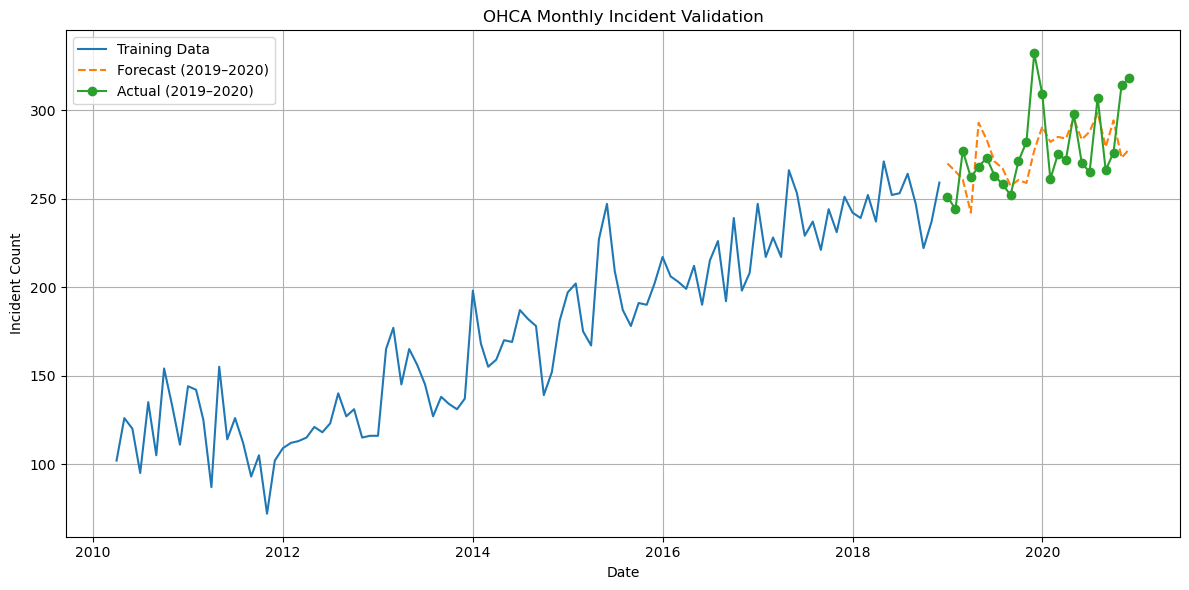

In [95]:
# training
model = Prophet(
    changepoint_prior_scale = 0.045809789125831474,
    seasonality_prior_scale = 12.134347263938931, 
    changepoint_range = 0.8407204094480383,
    interval_width = 0.9608824126083644,
    n_changepoints = 0, 
    # seasonality_mode = 'multiplicative',
    uncertainty_samples = 1500,
    # growth = 'linear',
    weekly_seasonality=False,
    daily_seasonality=False,
    yearly_seasonality = True,
)
model.fit(train_df)

# forecast the validation span
# MS: month start
future_validation = model.make_future_dataframe(periods=len(validate_df), freq="MS")[-len(validate_df):]
forecast_validation = model.predict(future_validation)[["ds", "yhat"]]

# align and evaluate
validation_comparison = validate_df.merge(forecast_validation, on = "ds")
mae_val  = mean_absolute_error(validation_comparison['y'], validation_comparison['yhat'])
rmse_val = np.sqrt(mean_squared_error(validation_comparison['y'], validation_comparison['yhat']))
print(f'VALIDATION:  \nMAE={mae_val:.1f}   \nRMSE={rmse_val:.1f}')


plt.figure(figsize = (12, 6))
plt.plot(train_df['ds'], train_df['y'], label='Training Data')
plt.plot(validation_comparison['ds'], validation_comparison['yhat'], label='Forecast (2019–2020)', linestyle='--')
plt.plot(validate_df['ds'], validate_df['y'], label='Actual (2019–2020)', marker='o')
plt.title("OHCA Monthly Incident Validation")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Testing

In [96]:
# retrain on train and validation set
combined_df = pd.concat([train_df, validate_df], ignore_index=True)

model_testing = Prophet(
    changepoint_prior_scale = 0.045809789125831474,
    seasonality_prior_scale = 12.134347263938931, 
    changepoint_range = 0.8407204094480383,
    interval_width = 0.9608824126083644,
    n_changepoints = 25, 
    # seasonality_mode = 'multiplicative',
    uncertainty_samples = 1500,
    # growth = 'linear',
    weekly_seasonality=False,
    daily_seasonality=False,
    yearly_seasonality = True,
)
model_testing.fit(combined_df)

future_test = model_testing.make_future_dataframe(periods=len(test_df), freq='MS')[-len(test_df):]
forecast_test = model_testing.predict(future_test)[['ds','yhat']]

# print(forecast_test)
# print(test_df)

test_cmp = test_df.merge(forecast_test, on='ds')
mae_test  = mean_absolute_error(test_cmp['y'], test_cmp['yhat'])
rmse_test = np.sqrt(mean_squared_error(test_cmp['y'], test_cmp['yhat']))
print(f'TEST  \nMAE={mae_test:.1f}   \nRMSE={rmse_test:.1f}')

15:46:41 - cmdstanpy - INFO - Chain [1] start processing
15:46:41 - cmdstanpy - INFO - Chain [1] done processing


TEST  
MAE=23.6   
RMSE=32.0


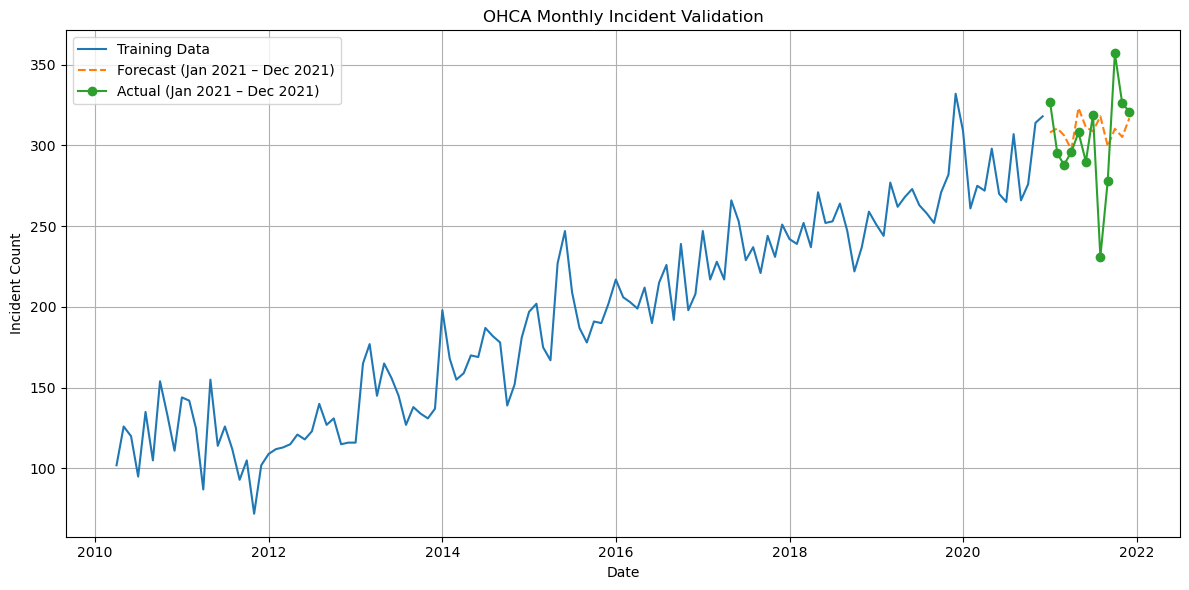

In [92]:
plt.figure(figsize = (12, 6))
plt.plot(combined_df['ds'], combined_df['y'], label='Training Data')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecast (Jan 2021 – Dec 2021)', linestyle='--')
plt.plot(test_df['ds'], test_df['y'], label='Actual (Jan 2021 – Dec 2021)', marker='o')
plt.title("OHCA Monthly Incident Validation")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Forecasting till 2040

In [8]:
# using month_count which is the whole OHCA count from 2010 april to 2021 december
df = month_count.copy()

model_forecasting = Prophet(
    changepoint_prior_scale = 0.045809789125831474,
    seasonality_prior_scale = 12.134347263938931, 
    changepoint_range = 0.8407204094480383,
    interval_width = 0.9608824126083644,
    n_changepoints = 0, 
    # seasonality_mode = 'multiplicative',
    uncertainty_samples = 1500,
    # growth = 'linear',
    weekly_seasonality=False,
    daily_seasonality=False,
    yearly_seasonality = True,
)
model_forecasting.fit(df)

10:58:04 - cmdstanpy - INFO - Chain [1] start processing
10:58:04 - cmdstanpy - INFO - Chain [1] done processing
10:58:04 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
10:58:04 - cmdstanpy - INFO - Chain [1] start processing
10:58:04 - cmdstanpy - INFO - Chain [1] done processing


252


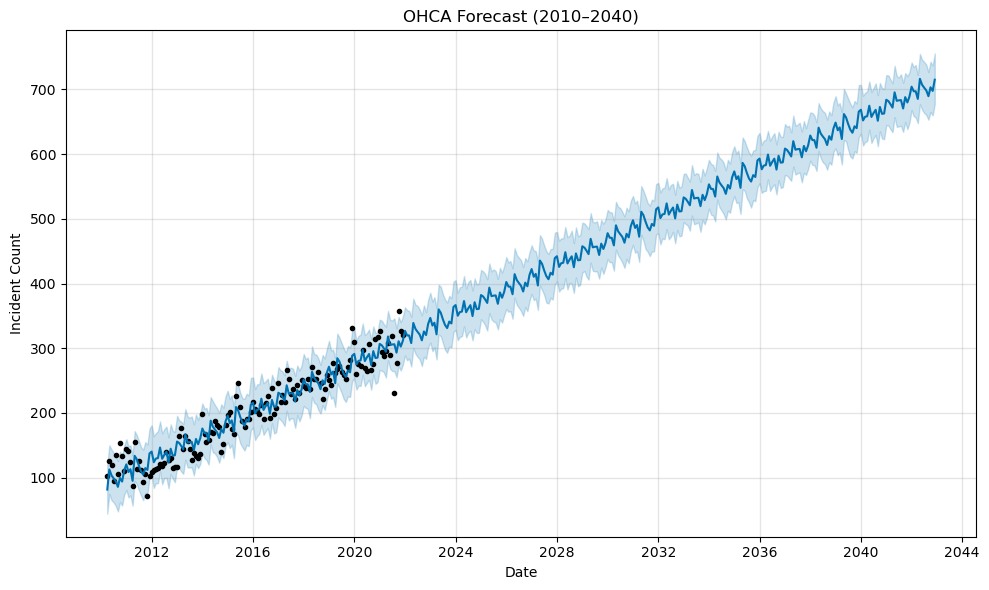

In [9]:
# last_date = df["ds"].max()
# print(last_date)
months_to_2040 = (2040 - 2021) * 12 + (24)


print(months_to_2040)
# make future dataframe
future = model_forecasting.make_future_dataframe(periods=months_to_2040, freq='MS')
# forecast
forecast = model_forecasting.predict(future)

import matplotlib.pyplot as plt

fig = model_forecasting.plot(forecast)
plt.title("OHCA Forecast (2010–2040)")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.tight_layout()
plt.show()

In [10]:
print(forecast)

            ds       trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
0   2010-04-01   91.523733   44.342530  119.924455    91.523733    91.523733   
1   2010-05-01   93.073431   74.986910  149.975170    93.073431    93.073431   
2   2010-06-01   94.674786   65.131094  143.749715    94.674786    94.674786   
3   2010-07-01   96.224485   61.968291  138.469065    96.224485    96.224485   
4   2010-08-01   97.825839   56.702305  134.086332    97.825839    97.825839   
..         ...         ...         ...         ...          ...          ...   
388 2042-08-01  701.588297  660.646431  738.460212   701.588279   701.588314   
389 2042-09-01  703.189652  653.226000  726.966621   703.189634   703.189669   
390 2042-10-01  704.739350  665.157046  742.938542   704.739332   704.739367   
391 2042-11-01  706.340705  660.091608  737.181950   706.340687   706.340722   
392 2042-12-01  707.890404  677.538361  755.856011   707.890385   707.890421   

     additive_terms  additive_terms_low

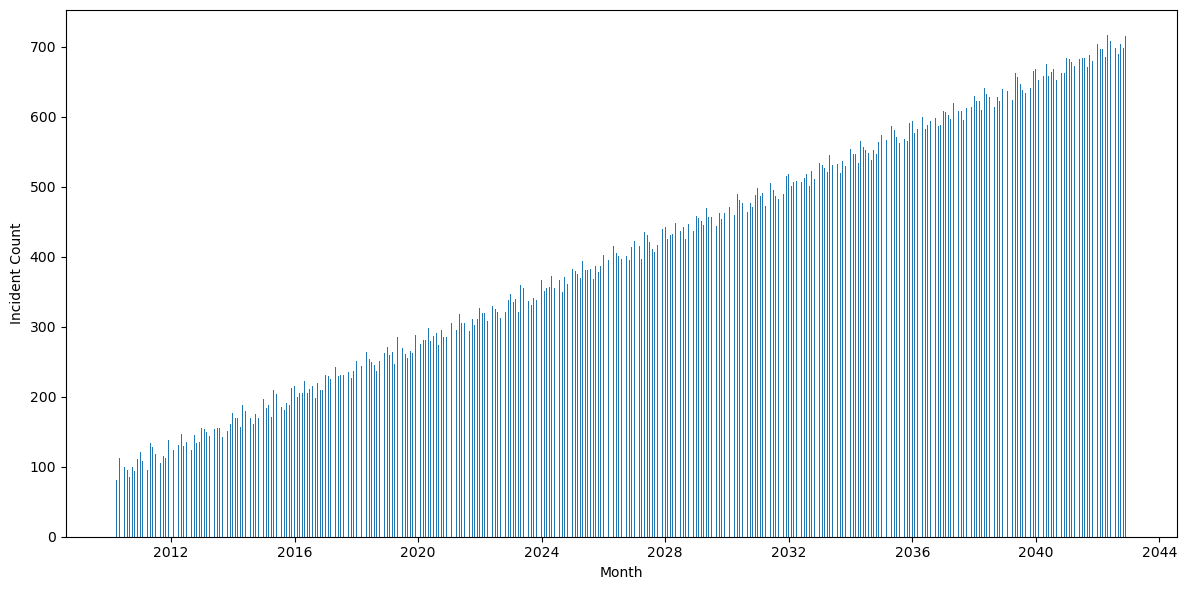

In [11]:
forecasted_df = forecast[["ds", "yhat"]]

plt.figure(figsize = (12, 6))
plt.bar(forecasted_df["ds"], forecasted_df["yhat"], width = 10)
plt.xlabel("Month")
plt.ylabel("Incident Count")
plt.tight_layout()
plt.show()

In [12]:
# extract year into a new column
forecasted_df["Year"] = forecasted_df["ds"].dt.year

# extract month into a new column
forecasted_df["Month"] = forecasted_df["ds"].dt.to_period("M").astype(str)

# extract quarter into a new column
forecasted_df["Quarter"] = forecasted_df["ds"].dt.to_period("Q").astype(str)
check_nan = forecasted_df[['Year','Month', 'Quarter']].isna().any()
print(check_nan)
print(forecasted_df)

Year       False
Month      False
Quarter    False
dtype: bool
            ds        yhat  Year    Month Quarter
0   2010-04-01   81.657129  2010  2010-04  2010Q2
1   2010-05-01  112.728333  2010  2010-05  2010Q2
2   2010-06-01  103.570706  2010  2010-06  2010Q2
3   2010-07-01   99.060256  2010  2010-07  2010Q3
4   2010-08-01   94.786610  2010  2010-08  2010Q3
..         ...         ...   ...      ...     ...
388 2042-08-01  698.549068  2042  2042-08  2042Q3
389 2042-09-01  689.620264  2042  2042-09  2042Q3
390 2042-10-01  703.361285  2042  2042-10  2042Q4
391 2042-11-01  697.776572  2042  2042-11  2042Q4
392 2042-12-01  715.111988  2042  2042-12  2042Q4

[393 rows x 5 columns]


/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_3525/3427889971.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecasted_df["Year"] = forecasted_df["ds"].dt.year
/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_3525/3427889971.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecasted_df["Month"] = forecasted_df["ds"].dt.to_period("M").astype(str)
/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_3525/3427889971.py:8: SettingWithCopyWarning: 
A value is trying to be s

In [13]:
forecast_by_year = forecasted_df.groupby("Year")["yhat"].sum().reset_index()

forecast_by_month = forecasted_df.groupby("Month")["yhat"].sum().reset_index()

forecast_by_quarter = forecasted_df.groupby("Quarter")["yhat"].sum().reset_index()

print(forecast_by_month)

       Month        yhat
0    2010-04   81.657129
1    2010-05  112.728333
2    2010-06  103.570706
3    2010-07   99.060256
4    2010-08   94.786610
..       ...         ...
388  2042-08  698.549068
389  2042-09  689.620264
390  2042-10  703.361285
391  2042-11  697.776572
392  2042-12  715.111988

[393 rows x 2 columns]


In [22]:
print(forecast_by_year[forecast_by_year["Year"] > 2021]["yhat"])

12    3887.022553
13    4113.951428
14    4329.275101
15    4565.718893
16    4792.666240
17    5019.595115
18    5234.918788
19    5471.362580
20    5698.309926
21    5925.238801
22    6140.562475
23    6377.006267
24    6603.953613
25    6830.882488
26    7046.206161
27    7282.649953
28    7509.597300
29    7736.526175
30    7951.849848
31    8188.293640
32    8415.240987
Name: yhat, dtype: float64


In [14]:
# Function to add centered value labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2,  # x position (center of bar)
                height + 5,                        # y position (just above the bar)
                f'{height:.0f}',                   # label (no decimal)
                ha='center', va='bottom', fontsize=9)


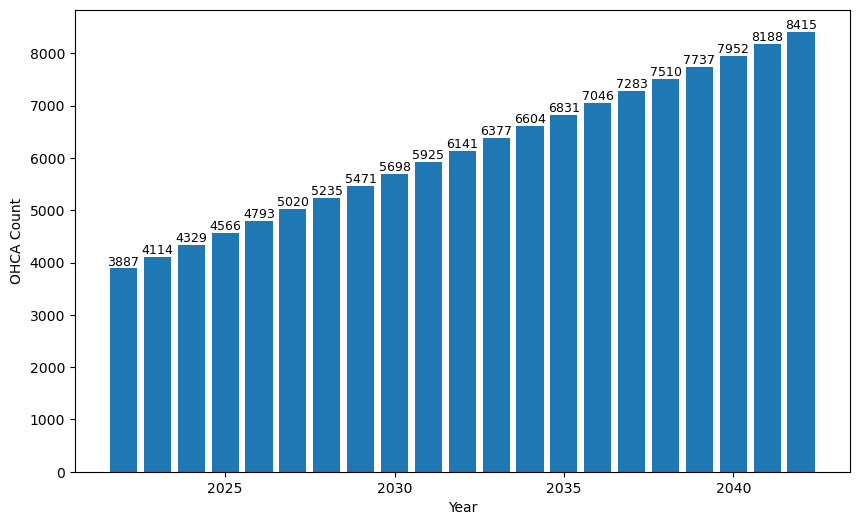

In [ ]:
# plot for year 2022 - 2040
x = forecast_by_year[forecast_by_year["Year"] > 2021]["Year"]
y = forecast_by_year[forecast_by_year["Year"] > 2021]["yhat"]
plt.figure(figsize = (10, 6))
bars = plt.bar(x, y)
add_labels(bars)
plt.xlabel("Year")
plt.ylabel("OHCA Count")
# plt.tight_layout()
plt.show()